## Vijay Hanumandla
# Roll No: 23102C0071
# Experiment 1: Implement Regularization
# Subject: AML




## Aim: To implement Regularization
Linear Regression, Ridge Regression (L2 Regularization), and Lasso Regression (L1 Regularization) using a built-in dataset.

## Theory

Regularization is a technique used in machine learning to reduce overfitting and improve the generalization ability of a model.

Regularization adds a penalty term to the loss function to control the size of model coefficients.

### Types of Regularization

1. L1 Regularization (Lasso):
L1 regularization adds the absolute value of the coefficients as a penalty.

Loss = MSE + λ Σ|Bᵢ|

Lasso can reduce some coefficients to exactly zero, which can be useful for feature selection.

2. L2 Regularization (Ridge):
L2 regularization adds the squared values of the coefficients as a penalty.

Loss = MSE + λ ΣBᵢ²

Ridge reduces the magnitude of coefficients and helps prevent overfitting.

The parameter λ (called alpha in Scikit-learn) controls the strength of regularization.


#1) Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


#2) Load the built-in dataset

In [6]:
#diabetes dataset
data = load_diabetes()
X = data.data
y = data.target
print("Dataset Loaded successfully")
print("Number of samples: ", X.shape[0])
print("Number of samples: ", X.shape[1])

Dataset Loaded successfully
Number of samples:  442
Number of samples:  10


#3) Display the dataset

In [7]:
#convert dataset into a Dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


#4) Understanding X and y

## Dataset Description

The Diabetes dataset is a built-in regression dataset provided by Scikit-learn.

It contains 442 samples and 10 input features.

The features represent various medical measurements, while the target represents a quantitative measure of disease progression one year after baseline.

In this experiment:

X = Input features
y = Target variable

#5) Split the dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


#6) Standardize the features


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


#7) Implement normal Linear Regression
## 1. Linear Regression Without Regularization

Linear Regression is used as the baseline model. It does not apply any regularization penalty.

In [10]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE:", mse_linear)
print("R² Score:", r2_linear)

Linear Regression
MSE: 2900.1936284934823
R² Score: 0.45260276297191926


#8) Implement Ridge Regression- L2
## 2. Ridge Regression — L2 Regularization

Ridge Regression uses L2 regularization.

The penalty term is based on the squared values of the model coefficients.

The alpha parameter controls the strength of regularization.

In [11]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MSE:", mse_ridge)
print("R² Score:", r2_ridge)

Ridge Regression
MSE: 2892.0145657501726
R² Score: 0.45414652070698225


#9) Implement Lasso Regression — L1
## 3. Lasso Regression — L1 Regularization

Lasso Regression uses L1 regularization.

The penalty is based on the absolute values of the model coefficients.

Lasso can reduce some coefficients to zero, which can perform feature selection.

In [12]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression")
print("MSE:", mse_lasso)
print("R² Score:", r2_lasso)

Lasso Regression
MSE: 2884.6242887352123
R² Score: 0.45554139902790414


#10) Compare the three models

In [13]:
## Model Comparison

In [14]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression (L2)",
        "Lasso Regression (L1)"
    ],
    "MSE": [
        mse_linear,
        mse_ridge,
        mse_lasso
    ],
    "R2 Score": [
        r2_linear,
        r2_ridge,
        r2_lasso
    ]
})

results

,Model,MSE,R2 Score
0,Linear Regression,2900.193628,0.452603
1,Ridge Regression (L2),2892.014566,0.454147
2,Lasso Regression (L1),2884.624289,0.455541


#11) Compare coefficients

In [15]:
coefficient_comparison = pd.DataFrame({
    "Feature": data.feature_names,
    "Linear Regression": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coefficient_comparison

,Feature,Linear Regression,Ridge,Lasso
0,age,1.753758,1.807342,1.730451
1,sex,-11.511809,-11.448190,-11.316359
2,bmi,25.607121,25.732699,25.824627
3,bp,16.828872,16.734300,16.644252
4,s1,-44.448856,-34.671954,-29.358412
5,s2,24.640954,17.053075,13.275844
6,s3,7.676978,3.369914,0.547948
7,s4,13.138784,11.764260,10.236168
8,s5,35.161195,31.378384,29.632826
9,s6,2.351364,2.458139,2.393475


#12) Plot the coefficients

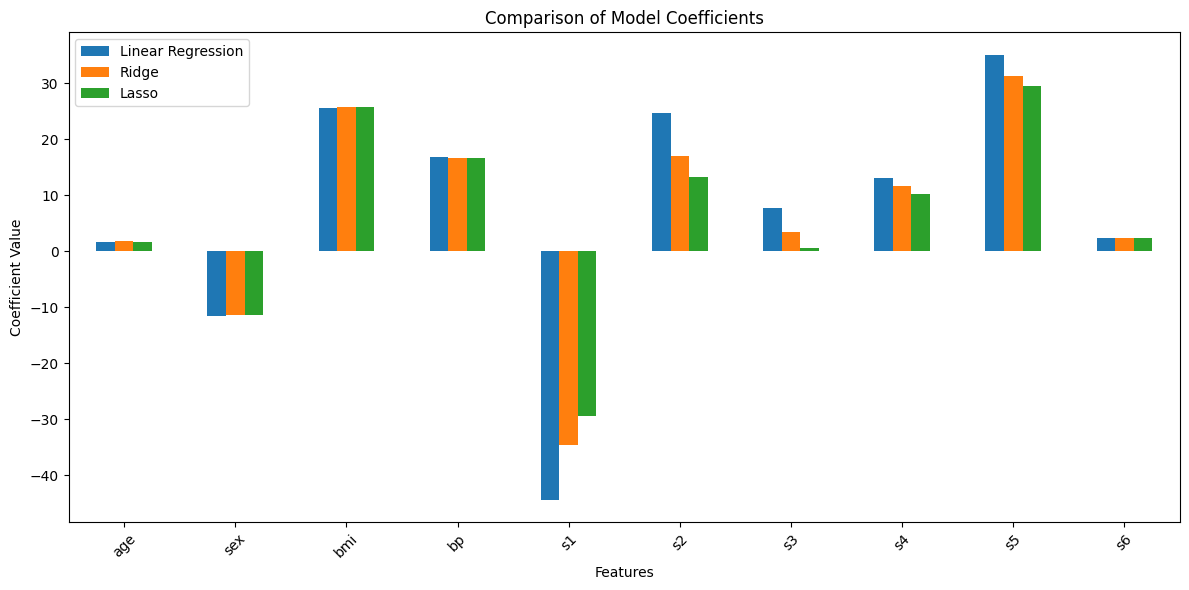

In [16]:
coefficient_comparison.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Model Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#13) Experiment with different alpha values

## Effect of Regularization Strength

The alpha parameter controls the strength of regularization.

We will test different alpha values and observe their effect on the Ridge Regression model.

In [17]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    ridge_results.append([alpha, mse, r2])

ridge_df = pd.DataFrame(
    ridge_results,
    columns=["Alpha", "MSE", "R2 Score"]
)

ridge_df

,Alpha,MSE,R2 Score
0,0.01,2900.075130,0.452625
1,0.10,2899.054556,0.452818
2,1.00,2892.014566,0.454147
3,10.00,2875.778718,0.457211
4,100.00,2858.224287,0.460524


#14) Plot Alpha vs R²

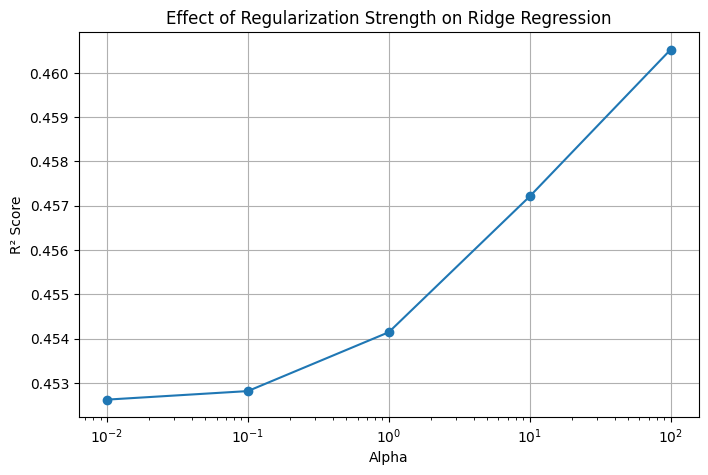

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(ridge_df["Alpha"], ridge_df["R2 Score"], marker="o")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Effect of Regularization Strength on Ridge Regression")
plt.grid(True)

plt.show()

##15) Final Conclusion

In this experiment, regularization was implemented using Ridge Regression (L2) and Lasso Regression (L1) on the Scikit-learn Diabetes dataset.

Linear Regression was first implemented as a baseline model. Ridge Regression reduced the magnitude of model coefficients using an L2 penalty, while Lasso Regression used an L1 penalty and can reduce some coefficients to zero.

Different alpha values were also tested to observe the effect of regularization strength on model performance.

Regularization is useful for reducing overfitting, controlling model complexity, and improving the generalization of machine learning models.